<a href="https://colab.research.google.com/github/wahiwatkar06-gif/mdm-practicals/blob/main/practical_no_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
file = "wireless_signal_kmeans_dataset.csv"

In [ ]:
data = pd.read_csv(file)

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 1 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   RSSI,RSRP,RSRQ,SNR,Latency,Packet_Loss  149 non-null    object
dtypes: object(1)
memory usage: 1.3+ KB
None


In [ ]:
print(data.head())

  RSSI,RSRP,RSRQ,SNR,Latency,Packet_Loss
0                     -45,-75,-5,30,10,1
1                     -48,-78,-6,28,12,1
2                     -50,-80,-7,27,15,2
3                     -52,-82,-8,25,18,2
4                     -55,-85,-9,23,20,3


In [ ]:
if len(data.columns) == 1:

    print("CSV format issue detected. Repairing...")

    data = pd.read_csv(
        file,
        sep=",",
        engine="python"
    )

CSV format issue detected. Repairing...


In [ ]:
if len(data.columns) == 1:

    data = data.iloc[:,0].str.split(
        ",",
        expand=True
    )

In [ ]:
data.columns = [
        "RSSI",
        "RSRP",
        "RSRQ",
        "SNR",
        "Latency",
        "Packet_Loss"
    ]

data.columns = data.columns.str.strip()

In [ ]:
print("\nDataset Columns:")
print(data.columns)


print("\nDataset Preview:")
print(data.head())




Dataset Columns:
Index(['RSSI', 'RSRP', 'RSRQ', 'SNR', 'Latency', 'Packet_Loss'], dtype='object')

Dataset Preview:
  RSSI RSRP RSRQ SNR Latency Packet_Loss
0  -45  -75   -5  30      10           1
1  -48  -78   -6  28      12           1
2  -50  -80   -7  27      15           2
3  -52  -82   -8  25      18           2
4  -55  -85   -9  23      20           3


In [ ]:
data = data.dropna()

for col in data.columns:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

In [ ]:
data.dropna(inplace=True)

print("\nClean Dataset:")
print(data.head())


Clean Dataset:
   RSSI  RSRP  RSRQ  SNR  Latency  Packet_Loss
0   -45   -75    -5   30       10            1
1   -48   -78    -6   28       12            1
2   -50   -80    -7   27       15            2
3   -52   -82    -8   25       18            2
4   -55   -85    -9   23       20            3


In [ ]:
X = data[
    [
        "RSSI",
        "RSRP",
        "RSRQ",
        "SNR",
        "Latency",
        "Packet_Loss"
    ]
]

In [ ]:
scaler = StandardScaler()


X_scaled = scaler.fit_transform(
    X
)

In [ ]:
kmeans = KMeans(

    n_clusters=3,

    random_state=42,

    n_init=10

)

data["Cluster"] = kmeans.fit_predict(
    X_scaled
)

In [ ]:
print("\nCluster Count:")
print(
    data["Cluster"].value_counts()
)

cluster_strength = data.groupby(
    "Cluster"
)["RSSI"].mean()

print("\nAverage RSSI:")
print(cluster_strength)

sorted_cluster = cluster_strength.sort_values(
    ascending=False
)


Cluster Count:
Cluster
0    56
1    54
2    39
Name: count, dtype: int64

Average RSSI:
Cluster
0   -52.732143
1   -65.277778
2   -75.461538
Name: RSSI, dtype: float64



Signal Quality Groups:
     RSSI  Cluster Signal_Quality
0     -45        0           Good
1     -48        0           Good
2     -50        0           Good
3     -52        0           Good
4     -55        0           Good
..    ...      ...            ...
144   -72        2           Poor
145   -75        2           Poor
146   -68        1         Medium
147   -70        1         Medium
148   -72        2           Poor

[149 rows x 3 columns]


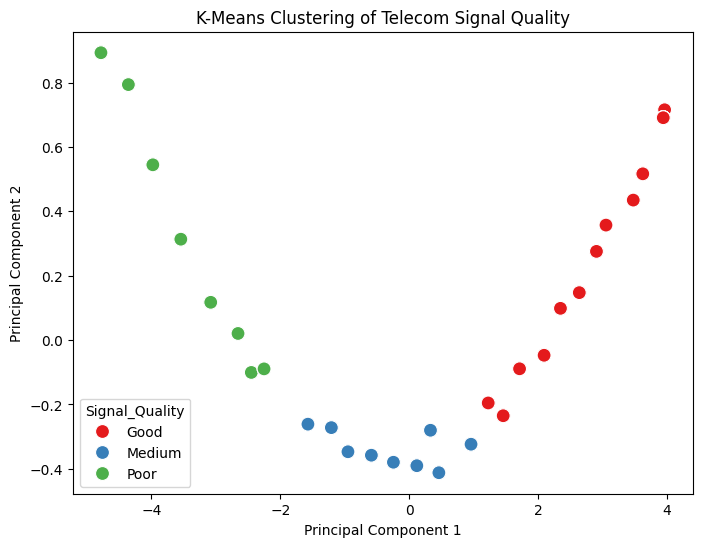

In [ ]:
quality = {

    sorted_cluster.index[0]: "Good",

    sorted_cluster.index[1]: "Medium",

    sorted_cluster.index[2]: "Poor"

}

data["Signal_Quality"] = data["Cluster"].map(
    quality
)

print("\nSignal Quality Groups:")
print(
    data[
        [
            "RSSI",
            "Cluster",
            "Signal_Quality"
        ]
    ]
)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))


sns.scatterplot(

    x=X_pca[:,0],

    y=X_pca[:,1],

    hue=data["Signal_Quality"],

    palette="Set1",

    s=100

)


plt.title(
    "K-Means Clustering of Telecom Signal Quality"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.show()

In [ ]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)


print("\nCluster Centers:")


print(
    pd.DataFrame(
        centers,
        columns=X.columns
    )
)


Cluster Centers:
        RSSI        RSRP       RSRQ        SNR    Latency  Packet_Loss
0 -52.732143  -82.732143  -7.857143  24.607143  18.303571     2.642857
1 -65.277778  -95.277778 -12.907407  14.000000  46.388889     8.314815
2 -75.461538 -105.461538 -16.974359   5.923077  95.128205    18.641026


In [ ]:
new_signal = [[

    -55,   # RSSI

    -85,   # RSRP

    -9,    # RSRQ

    23,    # SNR

    20,    # Latency

    3      # Packet Loss

]]

new_scaled = scaler.transform(
    new_signal
)

cluster = kmeans.predict(
    new_scaled
)

print("\nNew Signal Cluster:")
print(cluster[0])
print(
    "Signal Quality:",
    quality[cluster[0]]
)


New Signal Cluster:
0
Signal Quality: Good


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
